In [1]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import NEOMOD3 as nm3
import NEOfaster as nf
import neoscore as nsc
import S3Marray as sm
import S3M_fullversion as smfull

In [3]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

#### this is with the "refactored" python file: neoscore

In [4]:
# Initialize the scorer once with the 4D grid to use it
scorer = nsc.NEOMODScorer(array4D, H_center, a_center, e_center, i_center)

result = scorer.compute_score(
    obstime_str="2025-09-23T00:00:00",
    ra_deg=10.0, dec_deg=20.0,
    dra_deg_per_day=0.12, ddec_deg_per_day=0.22,
    mag=24.0,
    d_au=0.2, ddot_kms=3.0
)

print(f"Score: {result['score']}")
print(f"a: {result['a']}")
print(f"e: {result['e']}")
print(f"i: {result['i']}")
print(f"H: {result['H']}")

Score: 155.21
a: 1.8147948989466396
e: 0.35850436140431774
i: 3.646480531805697
H: 26.159186480177784


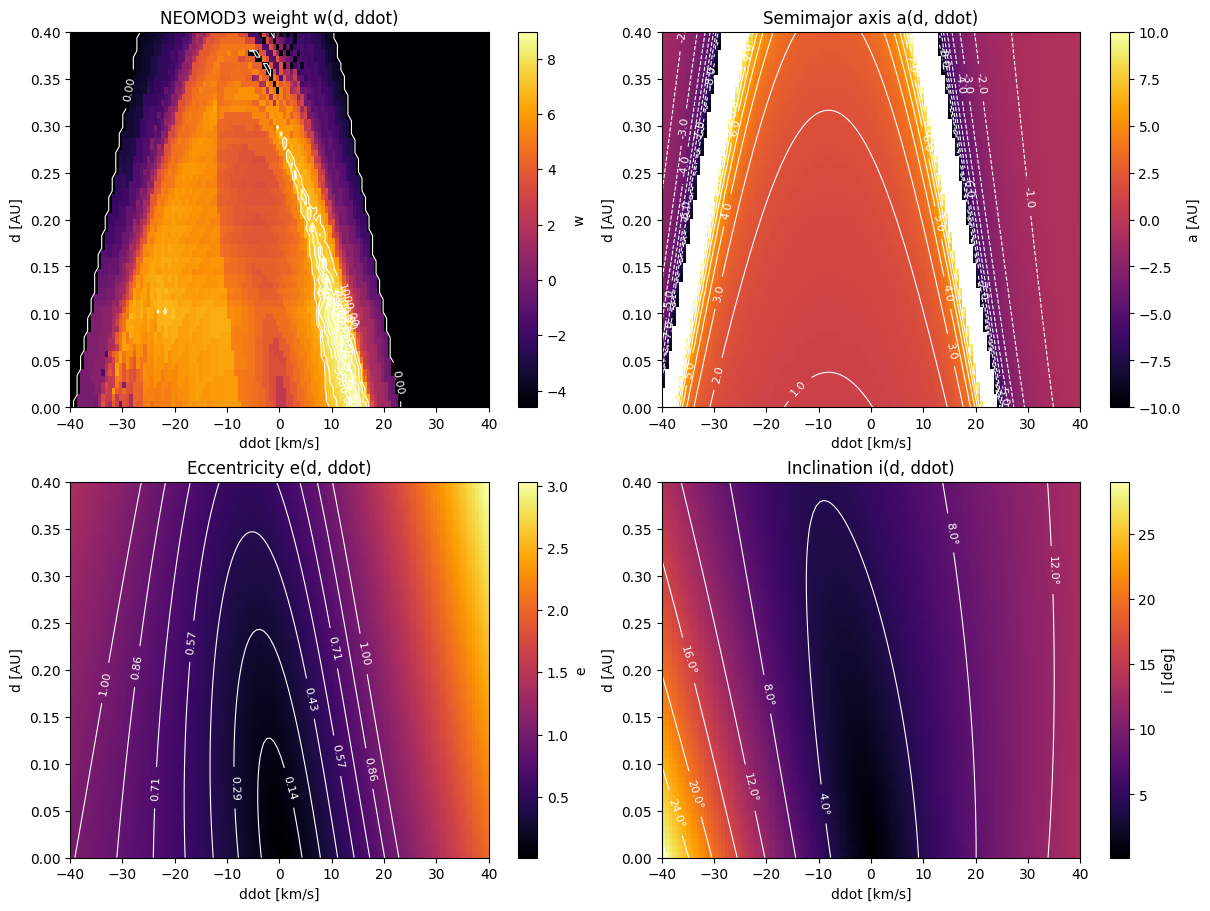

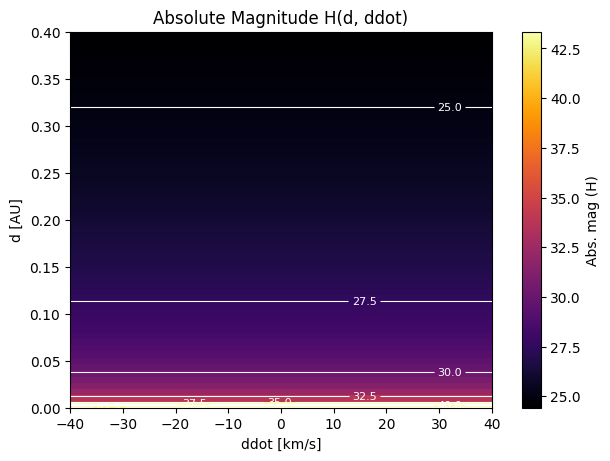

In [5]:
from matplotlib.colors import TwoSlopeNorm

# Define the grid
d_min, d_max, Nd = 0.00, 0.40, 60
v_min, v_max, Nv = -40.0, 40.0, 120
d_vals = np.linspace(d_min, d_max, Nd)
v_vals = np.linspace(v_min, v_max, Nv)

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra_deg, dec_deg = 10.0, 20.0
dra_deg_per_day, ddec_deg_per_day = 0.12, 0.22
mag = 24.0

# Computes the grids
W = np.zeros((Nd, Nv))
A = np.zeros((Nd, Nv))
E = np.zeros((Nd, Nv))
I = np.zeros((Nd, Nv))
H = np.zeros((Nd, Nv))

for i, d_au in enumerate(d_vals):
    for j, ddot_kms in enumerate(v_vals):
        result = scorer.compute_score(
            obstime_str, ra_deg, dec_deg,
            dra_deg_per_day, ddec_deg_per_day, mag,
            d_au, ddot_kms
        )
        W[i, j] = result['score']
        A[i, j] = result['a']
        E[i, j] = result['e']
        I[i, j] = result['i']
        H[i, j] = result['H']

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]

im0 = axs[0, 0].imshow(np.log(W + 0.01), origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# Semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(A_mask, origin="lower", extent=extent, aspect="auto", cmap="inferno", norm=norm)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

# Eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

# Inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

# Absolute magnitude
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
contH = axH.contour(v_vals, d_vals, H, levels=8, colors='white', linewidths=0.8)
axH.clabel(contH, inline=True, fontsize=8, fmt="%.1f")
axH.set_title("Absolute Magnitude H(d, ddot)")
axH.set_xlabel("ddot [km/s]")
axH.set_ylabel("d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()

#### this is with the old python file: NEOfaster

In [6]:
# observables
obstime_str="2025-09-23T00:00:00" # observed time in UTC
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22 # ra, dec, change in ra, change in dec
mag = 24.0 # visual apparent magnitude

In [7]:
l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
neo_score, a, e, i, H = nf.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, mag, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)
print("H:", H)

neo_score: 155.21
a: 1.8147948989466396
e: 0.35850436140431774
i: 3.646480531805697
H: [26.15918648]


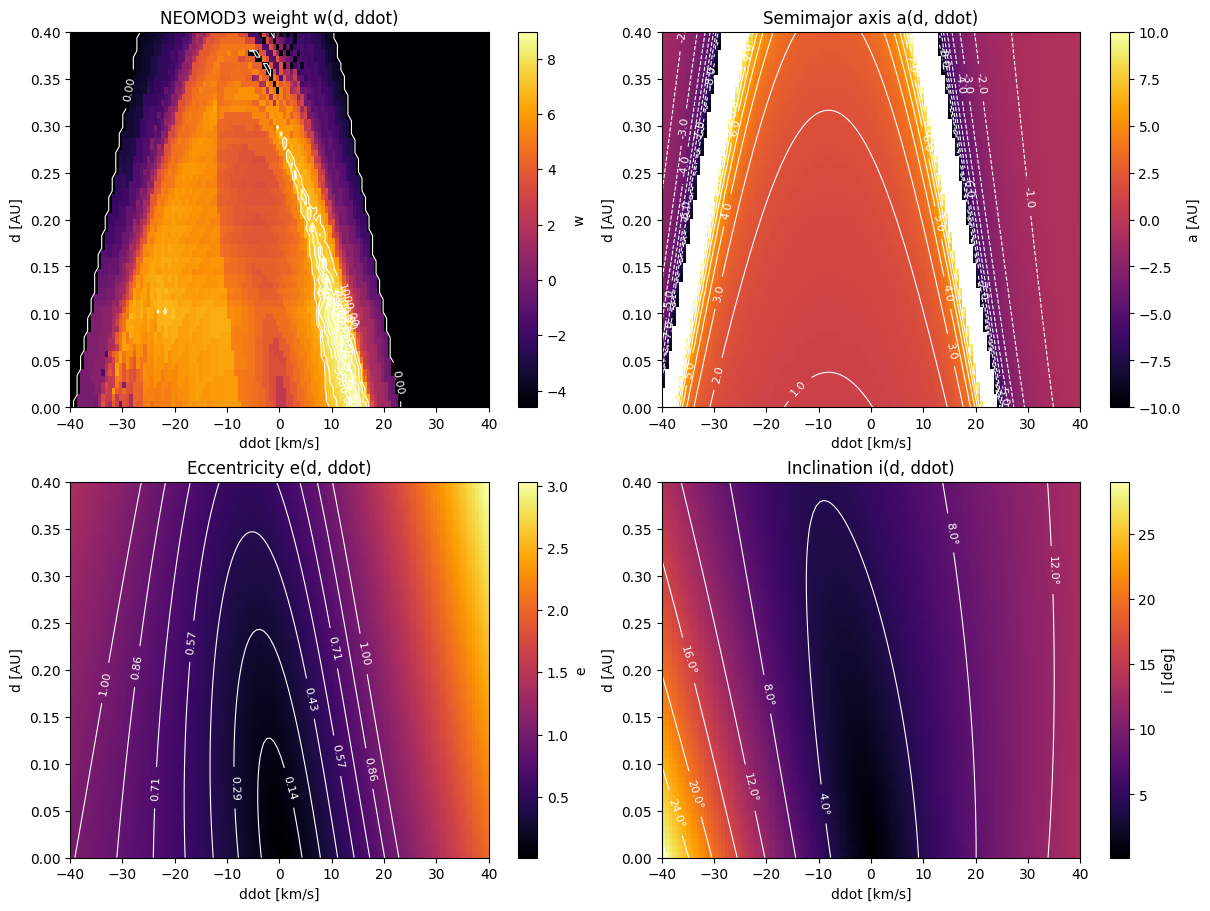

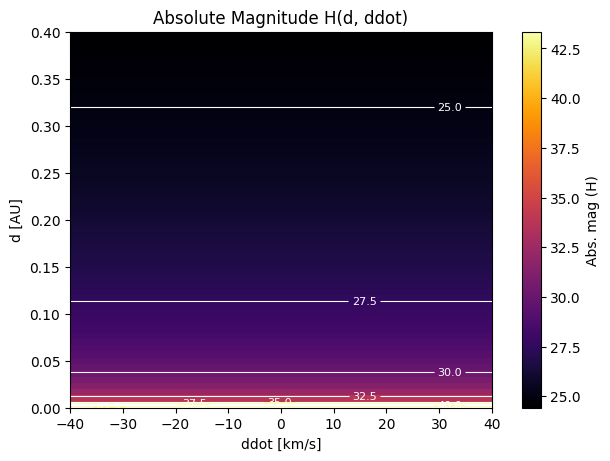

In [8]:
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import matplotlib.pyplot as plt

d_vals = np.linspace(0.00, 0.40,60)   
v_vals = np.linspace(-40.0, 40.0, 120)    


W = np.zeros((len(d_vals), len(v_vals)))   
A = np.zeros_like(W)                       
E = np.zeros_like(W)                       
I = np.zeros_like(W)   
H = np.zeros_like(W) 


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc, H_0= nf.compute_neomod3_weight(d, v, l_hat, v_hat, mag, obstime,
                           rE, vE, r_obs,
                           array4D, H_center, a_center, e_center, i_center) 
        H_0 = np.asarray(H_0).squeeze()
        
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc
        H[i,j] = np.asarray(H_0).item()


fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d

im0 = axs[0, 0].imshow(np.log(W + 0.01), origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")

fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(
    A_mask,
    origin="lower",
    extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
    aspect="auto",
    cmap="inferno",
    norm=norm,
)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

#inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

#absolute magnitude
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
contH = axH.contour(v_vals, d_vals, H, levels=8, colors='white', linewidths=0.8)
axH.clabel(contH, inline=True, fontsize=8, fmt="%.1f")
axH.set_title("Absolute Magnitude H(d, ddot)")
axH.set_xlabel("ddot [km/s]")
axH.set_ylabel("d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()

#### this is with the full version of s3m

In [9]:
s3m = sm.define_s3m()
s3m,array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = sm.s3m_array(s3m)

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [10]:
s3m_full = smfull.define_s3m()

['S0.s3m', 'S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m', 'SH.s3m', 'SI.s3m', 'SJ.s3m', 'SL.s3m', 'SR.s3m', 'SS.s3m', 'ST.s3m', 'St5.s3m']
The final df is done.


In [11]:
s3m,array4D_s3mfull, H_center_s3mfull, a_center_s3mfull, e_center_s3mfull, i_center_s3mfull = sm.s3m_array(s3m)

In [12]:
# Initialize the scorer once with the 4D grid to use it
scorer_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

result_s3m = scorer.compute_score(
    obstime_str="2025-09-23T00:00:00",
    ra_deg=359.9, dec_deg=-0.07,
    dra_deg_per_day=-0.188316, ddec_deg_per_day=-0.08016,
    mag=21.0,
    d_au=0, ddot_kms=3.0
)

print(f"Score: {result_s3m['score']}")
print(f"a: {result_s3m['a']}")
print(f"e: {result_s3m['e']}")
print(f"i: {result_s3m['i']}")
print(f"H: {result_s3m['H']}")

Score: 33.111
a: 1.0002018491964548
e: 0.07930526378609722
i: 0.009235168551452308
H: 40.346493183683194


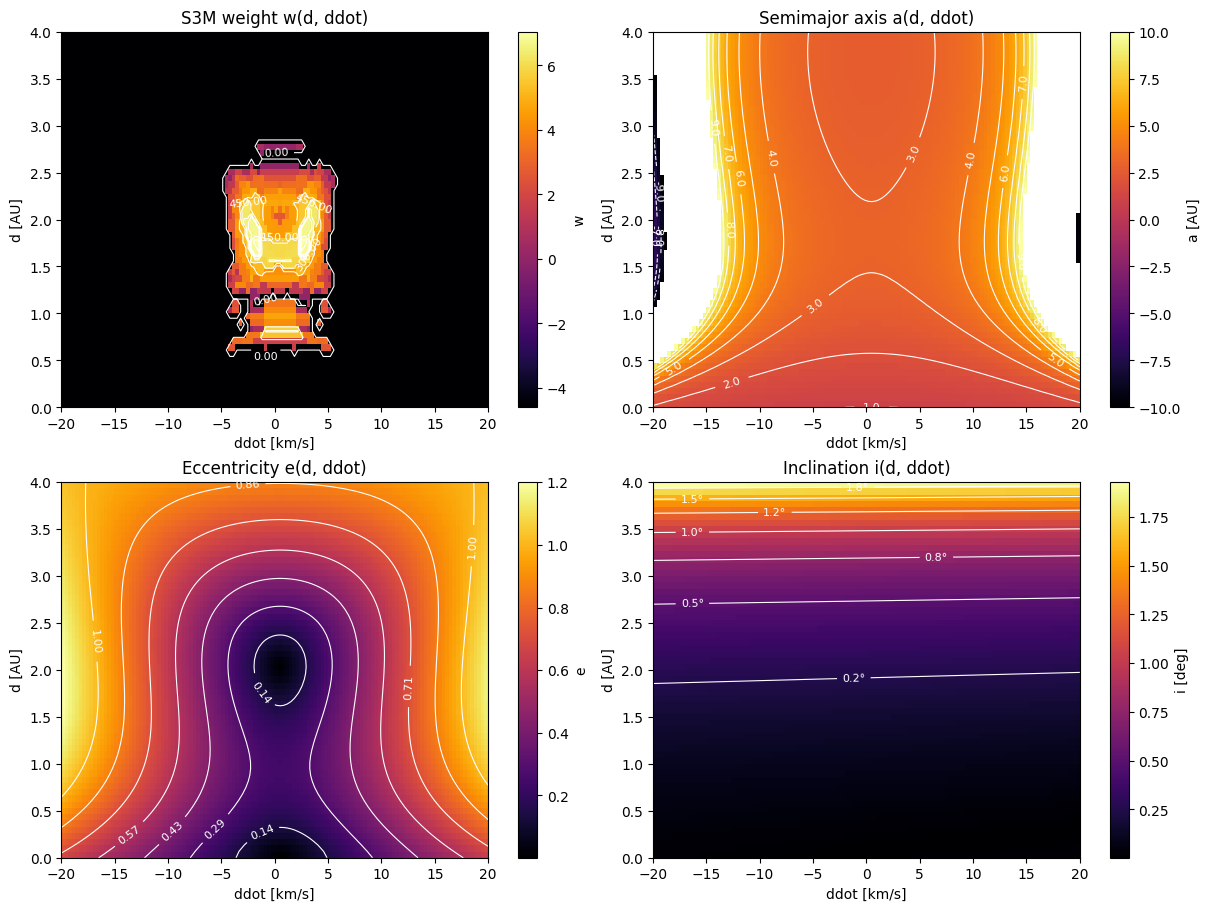

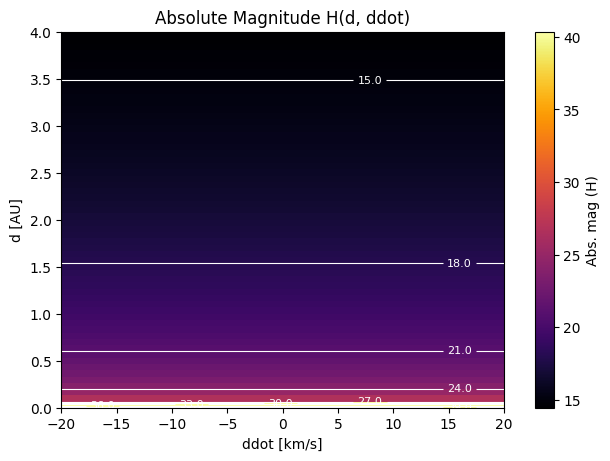

In [13]:
from matplotlib.colors import TwoSlopeNorm

# Define the grid
d_min, d_max, Nd = 0.00, 4.0, 60
v_min, v_max, Nv = -20.0, 20.0, 120
d_vals = np.linspace(d_min, d_max, Nd)
v_vals = np.linspace(v_min, v_max, Nv)

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra_deg, dec_deg = 359.9, -0.07
dra_deg_per_day, ddec_deg_per_day = -0.188316, -0.08016
mag = 21.0

# Computes the grids
W = np.zeros((Nd, Nv))
A = np.zeros((Nd, Nv))
E = np.zeros((Nd, Nv))
I = np.zeros((Nd, Nv))
H = np.zeros((Nd, Nv))

for i, d_au in enumerate(d_vals):
    for j, ddot_kms in enumerate(v_vals):
        result = scorer_s3m.compute_score(
            obstime_str, ra_deg, dec_deg,
            dra_deg_per_day, ddec_deg_per_day, mag,
            d_au, ddot_kms
        )
        W[i, j] = result['score']
        A[i, j] = result['a']
        E[i, j] = result['e']
        I[i, j] = result['i']
        H[i, j] = result['H']

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]

im0 = axs[0, 0].imshow(np.log(W + 1e-2), origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("S3M weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# Semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(A_mask, origin="lower", extent=extent, aspect="auto", cmap="inferno", norm=norm)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

# Eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

# Inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

# Absolute magnitude
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
contH = axH.contour(v_vals, d_vals, H, levels=8, colors='white', linewidths=0.8)
axH.clabel(contH, inline=True, fontsize=8, fmt="%.1f")
axH.set_title("Absolute Magnitude H(d, ddot)")
axH.set_xlabel("ddot [km/s]")
axH.set_ylabel("d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()

#### old code used for s3m

In [14]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 359.9, -0.07, -0.188316, -0.08016
# add mag here
mag = 21.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 

In [15]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 4.00, 60)
v_vals = np.linspace(-20.0, 20.0, 120)

W = np.zeros((len(d_vals), len(v_vals)))
A = np.zeros_like(W)
E = np.zeros_like(W)
I = np.zeros_like(W)
H = np.zeros_like(W)


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc, H_0 = nf.compute_neomod3_weight(
            d, v, l_hat, v_hat, mag, obstime, rE, vE, r_obs,
            array4D, H_center, a_center, e_center, i_center  
        )
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc
        H[i, j] = np.asarray(H_0).squeeze()


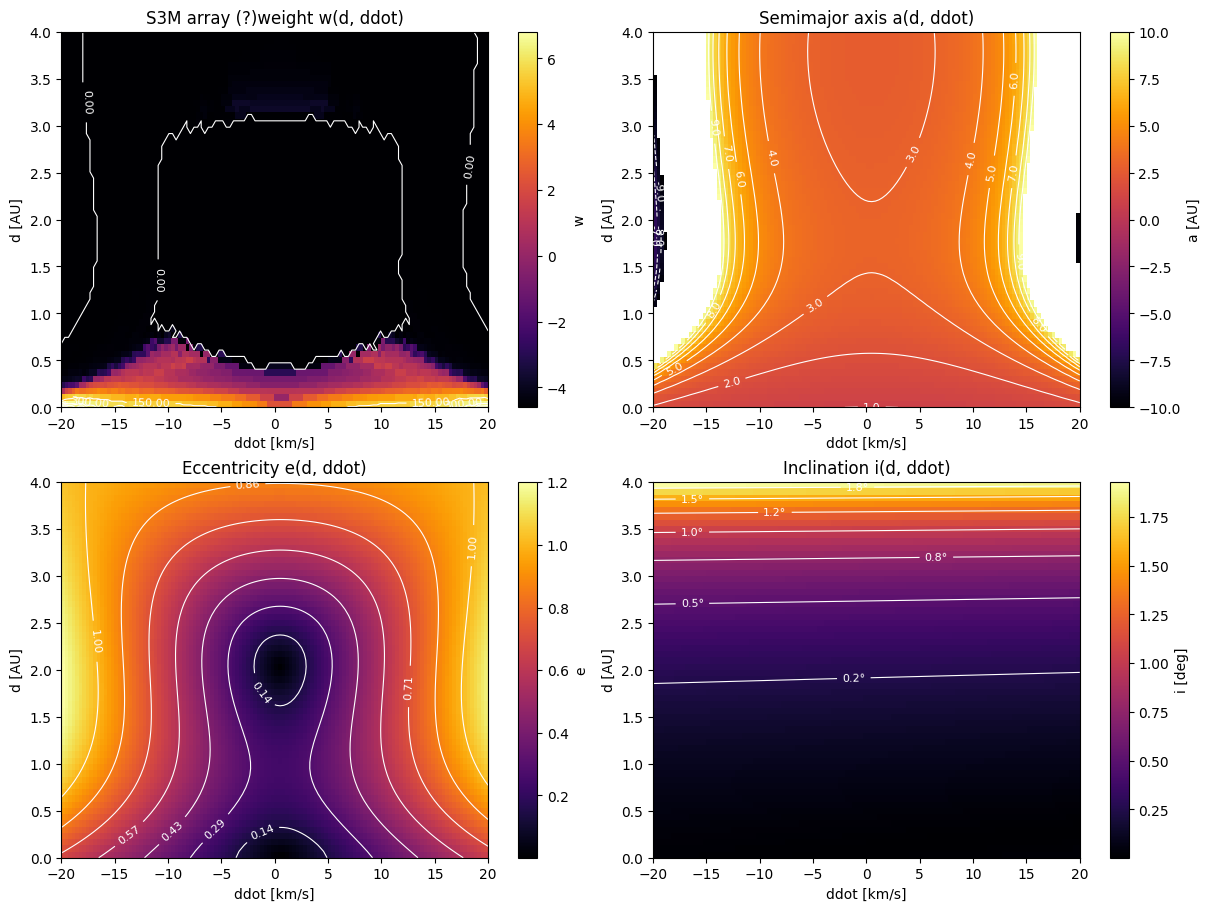

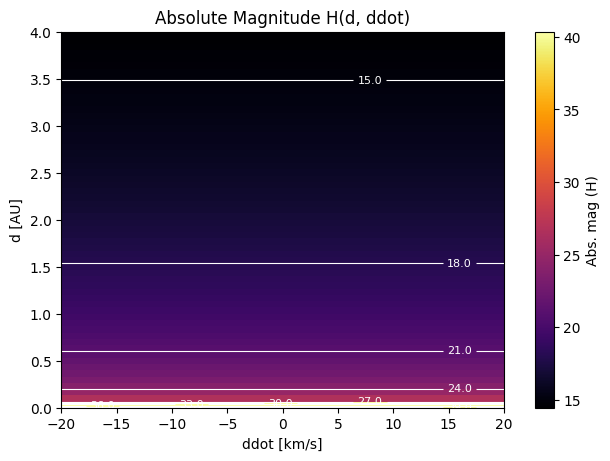

In [16]:
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# weight
im0 = axs[0, 0].imshow(np.log(W + 1e-2), origin="lower", extent=extent, aspect="auto", cmap="inferno")
c0  = axs[0, 0].contour(X, Y, W, levels=8, colors="white", linewidths=0.8)
axs[0, 0].clabel(c0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set(title="S3M array (?)weight w(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
A_mask = np.ma.masked_where(~np.isfinite(A) | (np.abs(A) > 10), A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
im1 = axs[0, 1].imshow(A_mask, origin="lower", extent=extent, aspect="auto", cmap="inferno", norm=norm)
cs1 = axs[0, 1].contour(X, Y, A_mask, levels=np.linspace(-10, 10, 21), colors="white", linewidths=0.8)
axs[0, 1].clabel(cs1, inline=True, fontsize=8, fmt="%.1f")
axs[0, 1].set(title="Semimajor axis a(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im1, ax=axs[0, 1], label="a [AU]")

# eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cs2 = axs[1, 0].contour(X, Y, E, levels=np.linspace(0, 1, 8), colors="white", linewidths=0.8)
axs[1, 0].clabel(cs2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set(title="Eccentricity e(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

# inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cs3 = axs[1, 1].contour(X, Y, I, levels=8, colors="white", linewidths=0.8)
axs[1, 1].clabel(cs3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set(title="Inclination i(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

# H panel
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
csH = axH.contour(X, Y, H, levels=8, colors="white", linewidths=0.8)
axH.clabel(csH, inline=True, fontsize=8, fmt="%.1f")
axH.set(title="Absolute Magnitude H(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()
